In [50]:
import pandas as pd
import numpy as np
import random
import os
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.family'] = 'AppleGothic'
mpl.rcParams['axes.unicode_minus'] = False

In [53]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(42) # Seed 고정

In [54]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# 데이터를 확인하기 위해 head() 함수를 사용합니다.
train.head(5)

,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
0,TRAIN_0000,35,170,70,24.22,1.10,1,98,40,80,1.3,211,75,120,15.9,1,1.53,1
1,TRAIN_0001,40,150,55,24.44,1.00,0,173,39,104,0.6,251,46,184,11.8,1,1.45,0
2,TRAIN_0002,60,170,50,17.30,0.75,0,96,40,61,0.8,144,43,89,15.3,1,1.04,0
3,TRAIN_0003,40,150,45,20.00,0.50,0,92,40,46,0.7,178,66,110,13.4,1,1.18,0
4,TRAIN_0004,55,155,65,27.06,1.00,0,87,42,95,0.9,232,62,151,13.8,1,1.32,0


In [55]:
test.head(5)

,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율
0,TEST_0000,40,165,55,20.20,0.90,1,98,47,75,0.5,229,59,155,13.7,1,1.73
1,TEST_0001,65,145,50,23.78,0.50,0,99,59,98,0.6,200,65,115,12.2,1,1.00
2,TEST_0002,40,160,75,29.30,1.00,0,105,34,232,0.6,170,50,73,15.1,1,1.33
3,TEST_0003,30,180,90,27.78,1.35,0,78,45,218,0.9,197,55,98,15.2,1,0.89
4,TEST_0004,50,155,55,22.89,0.75,0,116,67,139,1.0,230,66,136,15.0,1,0.85


In [57]:
train.isnull().sum()

ID          0
나이          0
키(cm)       0
몸무게(kg)     0
BMI         0
시력          0
충치          0
공복 혈당       0
혈압          0
중성 지방       0
혈청 크레아티닌    0
콜레스테롤       0
고밀도지단백      0
저밀도지단백      0
헤모글로빈       0
요 단백        0
간 효소율       0
label       0
dtype: int64

In [56]:
x_train = train.drop(['ID', 'label'], axis = 1)
y_train = train['label']

x_test = test.drop('ID', axis = 1)

In [128]:
# 키가 큰 값 10개 (내림차순)
train['간 효소율'].nlargest(10)

313     5.67
2967    5.47
5458    5.33
3665    5.17
1121    4.17
1006    4.00
2149    4.00
3394    4.00
5665    4.00
6090    4.00
Name: 간 효소율, dtype: float64

In [129]:
# 키가 작은 값 10개 (오름차순)
train['간 효소율'].nsmallest(80)

4200    0.14
2731    0.29
3940    0.31
1229    0.32
2286    0.34
        ... 
158     0.46
1427    0.46
2035    0.46
2839    0.46
3347    0.46
Name: 간 효소율, Length: 80, dtype: float64

In [135]:
hyliver= (train['간 효소율'] > 3 ).sum()
print(hyliver)

25


In [127]:
hyCr= (train['요 단백'] > 4).sum()
print(hyCr)

10


In [ ]:
hyeye= (train['시력'] > 3.0).sum()
print(hyeye)

In [120]:
hyHb= (train['헤모글로빈'] >= 18).sum()
print(hyHb)

44


In [101]:
hyLDL= (train['저밀도지단백'] < 30).sum()
print(hyLDL)

20


In [112]:
hyTG = (train['중성 지방'] > 500).sum()
print(hyTG)

1


In [114]:
lowTG = (train['중성 지방'] < 25).sum()
print(lowTG)

4


In [111]:
lowBP = (train['혈압'] <= 20).sum()
print(lowBP)

11


In [45]:
X_tr, X_val, y_tr, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,        
    random_state=42,
    stratify=y_train    
)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_tr, y_tr)

val_pred = model.predict(X_val)

val_acc = accuracy_score(y_val, val_pred)
print("검증 정확도(Validation Accuracy):", val_acc)

검증 정확도(Validation Accuracy): 0.6764285714285714


In [42]:
submit = pd.read_csv('sample_submission.csv')

In [10]:
# 예측한 값을 TARGET 컬럼에 할당합니다.
submit['label'] = pred
submit.head()

,ID,label
0,TEST_0000,0
1,TEST_0001,0
2,TEST_0002,1
3,TEST_0003,1
4,TEST_0004,0


In [12]:
# 예측한 결과를 파일로 저장합니다. index 인자의 값을 False로 설정하지 않으면 제출이 정상적으로 진행되지 않습니다.
submit.to_csv('submission.csv', index = False)

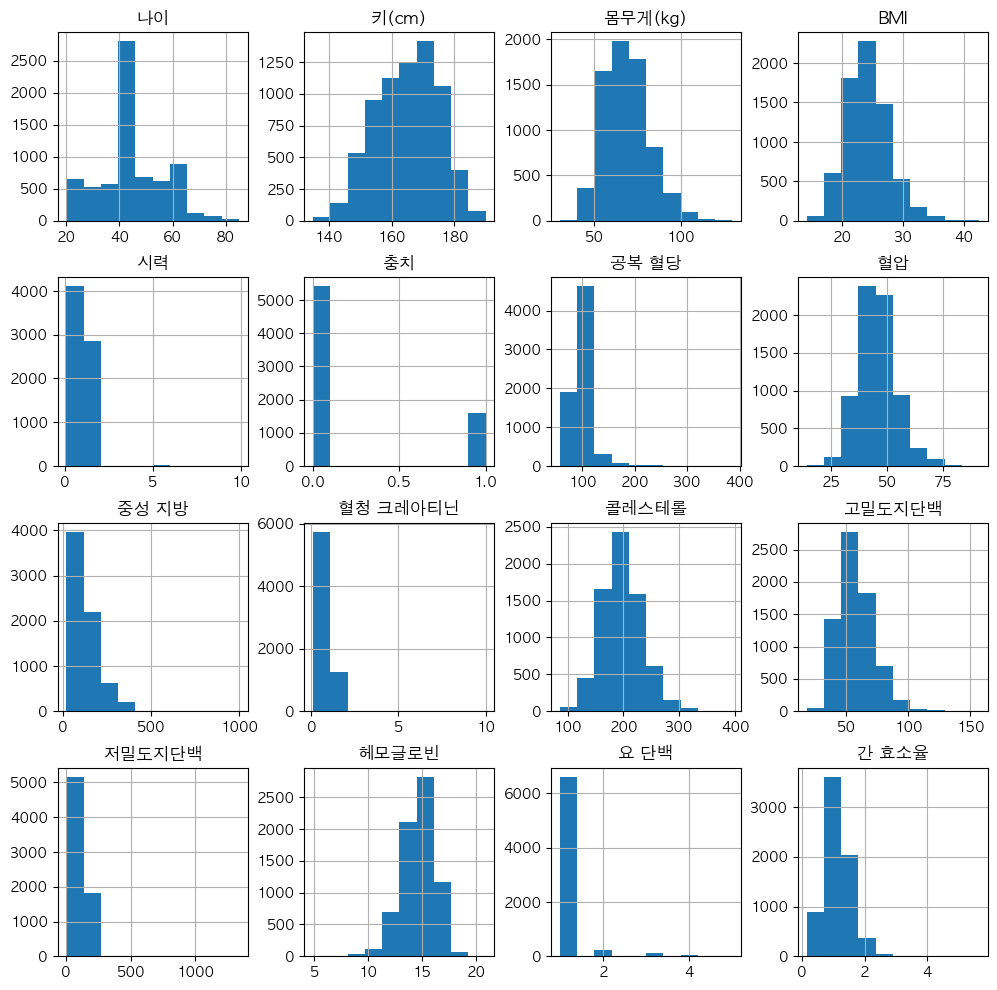

In [51]:
except_target = train.drop('label', axis = 1)
except_target.hist(figsize = (12,12))
plt.show()